# Analisa Data Menggunakan Regresi LInier

## Pengertian  Regresi Linier

Regresi linear adalah teknik analisis data yang memprediksi nilai data yang tidak diketahui dengan menggunakan nilai data lain yang terkait dan diketahui. Memprediksi sesuatu yang akan terjadi (continues value). Contoh: berapa jumlah penduduk, jumlah stok.

## Data awal

$$
\begin{array}{|c|c|c|}
\hline
\textbf{Titik} & \textbf{X (Variabel Independen)} & \textbf{Y (Variabel Dependen)} \\
\hline
A & 2 & 2 \\
B & 4 & 3 \\
C & 3 & 5 \\
D & 3 & 4 \\
E & 3 & 3 \\
F & 4 & 5 \\
G & 5 & 6 \\
\hline
\end{array}
$$

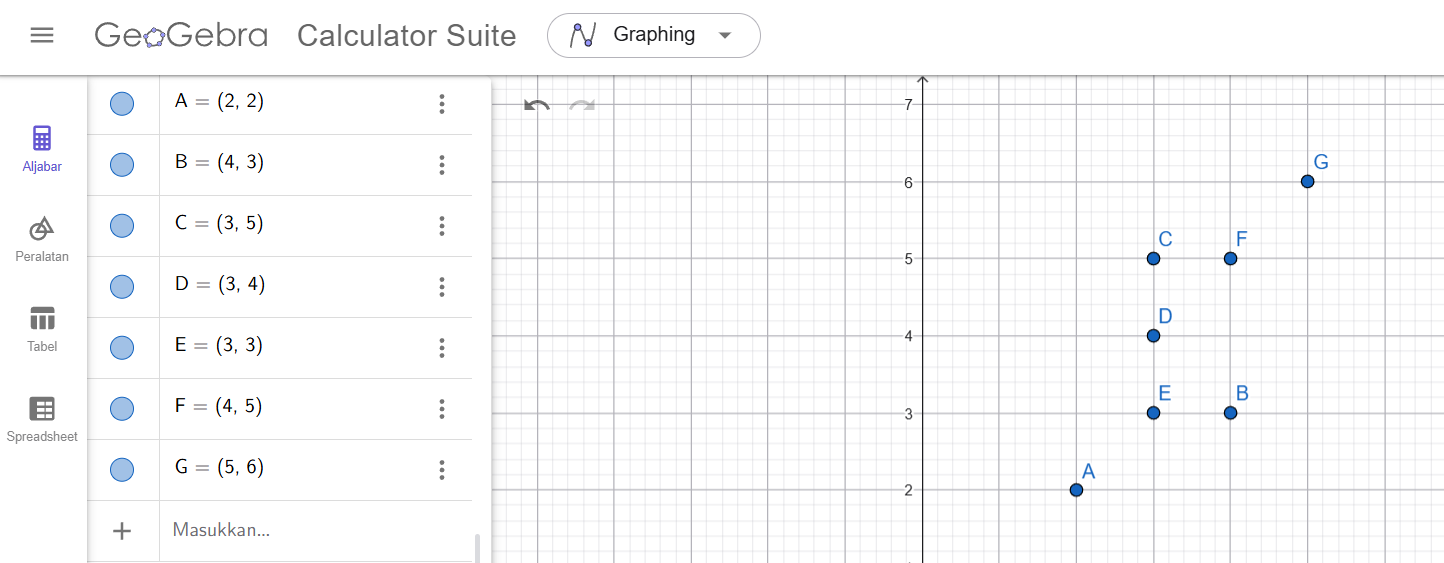

## Perhitungan Manual

### Estimasi Koefisien Regresi Linear

Untuk meminimalkan *Sum of Squared Errors* (SSE) secara analitis, kita dapat menggunakan **Persamaan Normal** berikut:

$$\hat{\beta} = (X^T X)^{-1} X^T Y$$

**Keterangan Simbol:**
* $\hat{\beta}$ : Vektor hasil estimasi koefisien (berisi nilai konstanta $a$ dan slope $b$).
* $X$ : Matriks variabel independen (ditambah kolom angka $1$ di awal untuk menghitung konstanta).
* $X^T$ : Transpose dari matriks $X$.
* $^{-1}$ : Invers matriks (dari hasil perkalian $X^T$ dan $X$).
* $Y$ : Vektor variabel dependen (nilai aktual observasi $y$).


### 1. Definisi Matriks X dan Y
Matriks $X$ berisi nilai variabel independen (ditambah kolom angka 1 untuk konstanta), dan matriks $Y$ berisi nilai variabel dependen.

$$ X = \begin{bmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 3 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{bmatrix}, \quad Y = \begin{bmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{bmatrix} $$

### 2. Menghitung X Transpose ($X^T$)
Mengubah posisi baris menjadi kolom pada matriks $X$.

$$ X^T = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{bmatrix} $$

### 3. Menghitung Perkalian $X^T * X$
Mengalikan matriks $X^T$ dengan matriks $X$.

$$X^T X = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{bmatrix} \begin{bmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 3 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{bmatrix} = \begin{bmatrix} 7 & 24 \\ 24 & 88 \end{bmatrix}$$

### 4. Menghitung Invers Matriks $(X^T X)^{-1}$
Langkah pertama adalah mencari determinan dari matriks $X^T X$:
$$\text{Det} = (7 \times 88) - (24 \times 24) = 616 - 576 = 40$$

Selanjutnya, kalikan adjoin matriks dengan $1 / \text{Det}$:
$$(X^T X)^{-1} = \frac{1}{40} \begin{bmatrix} 88 & -24 \\ -24 & 7 \end{bmatrix} = \begin{bmatrix} 2.2 & -0.6 \\ -0.6 & 0.175 \end{bmatrix}$$

### 5. Menghitung Perkalian $X^T * Y$
Mengalikan matriks $X^T$ dengan matriks $Y$.

$$X^T Y = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 & 1 \\ 2 & 4 & 3 & 3 & 3 & 4 & 5 \end{bmatrix} \begin{bmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{bmatrix} = \begin{bmatrix} 28 \\ 102 \end{bmatrix}$$

### 6. Menghitung Nilai B0 dan B1 ($\hat{\beta}$)
Langkah terakhir adalah mengalikan matriks Invers $(X^T X)^{-1}$ dengan matriks $X^T Y$.

$$\hat{\beta} = \begin{bmatrix} B_0 \\ B_1 \end{bmatrix} = \begin{bmatrix} 2.2 & -0.6 \\ -0.6 & 0.175 \end{bmatrix} \begin{bmatrix} 28 \\ 102 \end{bmatrix}$$

$$\hat{\beta} = \begin{bmatrix} (2.2 \times 28) + (-0.6 \times 102) \\ (-0.6 \times 28) + (0.175 \times 102) \end{bmatrix}$$

$$\hat{\beta} = \begin{bmatrix} 61.6 - 61.2 \\ -16.8 + 17.85 \end{bmatrix} = \begin{bmatrix} 0.4 \\ 1.05 \end{bmatrix}$$

**Kesimpulan:**
Dari hasil perkalian matriks di atas, didapatkan nilai Konstanta ($B_0$) = **0.4** dan nilai Kemiringan/Slope ($B_1$) = **1.05**.

Maka, persamaan regresinya adalah:
$$Y = 0.4 + 1.05X$$

Hasil Perhitungan Menggunakan Excel:

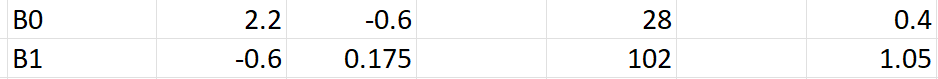

## Visualisas Garis Regresi

Pada visualisasi untuk hasil perhitungan manualnya saya menggunakan: https://www.geogebra.org/calculator

Berikut adalah hasilnya:


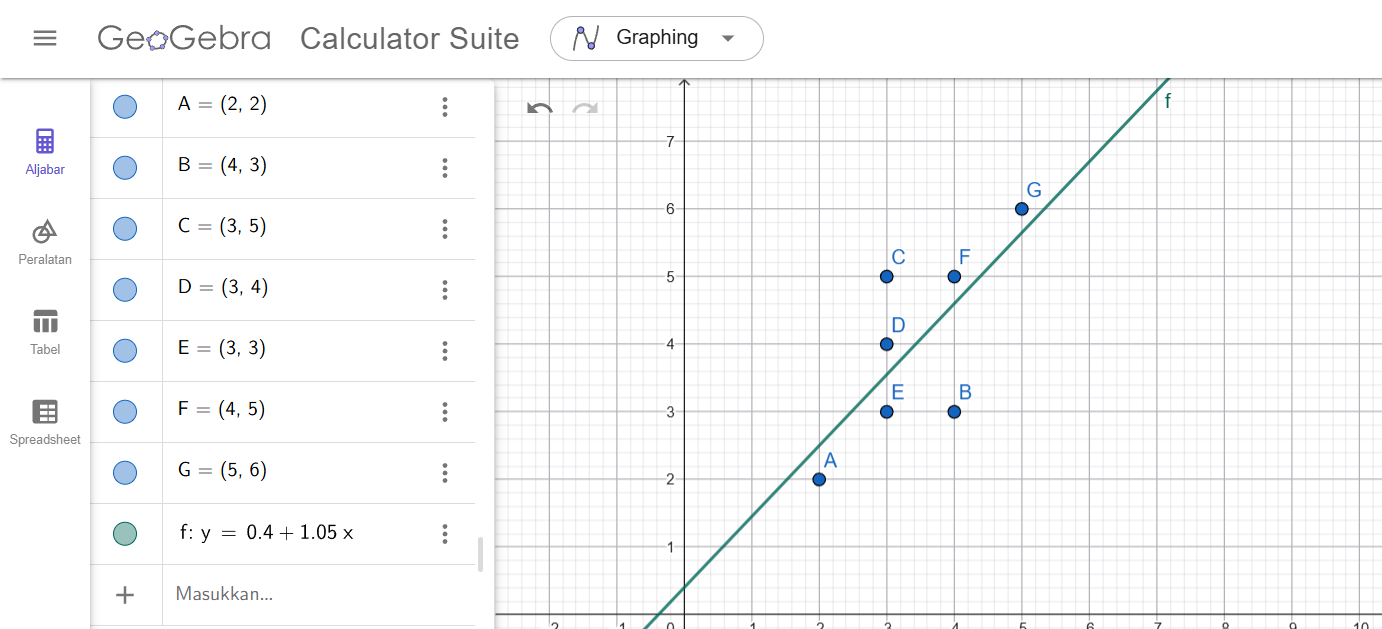

## Implementasi Pada Program

PREVIEW DATA
   X  Y
0  2  2
1  4  3
2  3  5
3  3  4
4  3  3
------------------------------

HASIL PERHITUNGAN
Persamaan Regresi: y = 0.40 + 1.05x



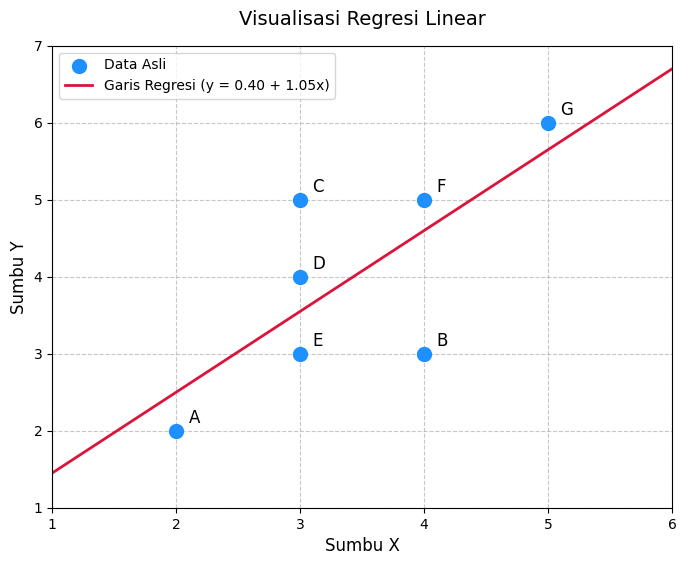

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Mendefinisikan Data menggunakan Pandas DataFrame
data = {
    'X': [2, 4, 3, 3, 3, 4, 5],
    'Y': [2, 3, 5, 4, 3, 5, 6]
}
df = pd.DataFrame(data)

# Menampilkan 5 baris pertama dari DataFrame
print("PREVIEW DATA")
print(df.head())
print("-" * 30 + "\n")

# Mengubah data dari DataFrame menjadi format array NumPy untuk scikit-learn
# Tanda kurung siku ganda [['X']] otomatis membuat array 2D yang dibutuhkan sklearn
X = df[['X']].values
Y = df['Y'].values

# 2. Membuat dan Melatih Model Regresi Linear
model = LinearRegression()
model.fit(X, Y)

# Mendapatkan nilai konstanta (a) dan koefisien (b)
a = model.intercept_
b = model.coef_[0]

print("HASIL PERHITUNGAN")
print(f"Persamaan Regresi: y = {a:.2f} + {b:.2f}x\n")

# 3. Membuat Data untuk Garis Regresi (Visualisasi)
x_line = np.linspace(1, 6, 100).reshape(-1, 1)
y_line = model.predict(x_line)

# 4. Membangun Visualisasi dengan Matplotlib
plt.figure(figsize=(8, 6))

# Membuat scatter plot menggunakan data dari kolom DataFrame
plt.scatter(df['X'], df['Y'], color='dodgerblue', label='Data Asli', s=100, zorder=5)

# Memberikan label huruf (A-G) dengan mengambil data dari DataFrame (.iloc)
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
for i, txt in enumerate(labels):
    plt.annotate(txt, (df['X'].iloc[i], df['Y'].iloc[i]), xytext=(df['X'].iloc[i]+0.1, df['Y'].iloc[i]+0.1), fontsize=12)

# Menggambar garis regresi linear (garis merah)
plt.plot(x_line, y_line, color='crimson', linewidth=2, label=f'Garis Regresi (y = {a:.2f} + {b:.2f}x)')

# Pengaturan tampilan grafik
plt.title('Visualisasi Regresi Linear', fontsize=14, pad=15)
plt.xlabel('Sumbu X', fontsize=12)
plt.ylabel('Sumbu Y', fontsize=12)

# Menentukan batas rentang sumbu x dan y agar terlihat rapi
plt.xlim(1, 6)
plt.ylim(1, 7)

# Menambahkan grid dan legenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')

plt.show()